
# **CLUSTERING ALGORITHMS**

## ***Overview***

This notebook implements four groups of clustering algorithms according to the datasets `train.csv`, `val.csv`, and `test.csv`:

- **Partition-based clustering**: K-Means  
- **Hierarchical clustering**: Agglomerative Clustering  
- **Density-based clustering**: DBSCAN  
- **Model-based clustering**: Gaussian Mixture Model (EM)  



# **1. Setup & Dependencies**

This section imports the necessary libraries for data preprocessing, model training, evaluation, and visualization.

In [1]:

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA
from sklearn.metrics import confusion_matrix, silhouette_score
from scipy.optimize import linear_sum_assignment

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


# **2. Data Acquisition**

This section covers data loading and provides an overview of the dataset.

## ***2.1. Load Train, Validation and Test Sets***

This section is responsible for loading the prepared datasets used for model training and evaluation. The data has been preprocessed and split into three subsets:

- **Training set**: used to fit the model  
- **Validation set**: used to adjust and select the best model. 
- **Test set**: used for final evaluation  

In [2]:
traindf = pd.read_csv("../data/processed/train.csv")
valdf = pd.read_csv("../data/processed/val.csv")
testdf = pd.read_csv("../data/processed/test.csv")

## ***2.2. Dataset Overview***

This step verifies the size and structure of each dataset split to ensure correctness after preprocessing and data splitting.

In [3]:
def summarize_dataset(name, df, total):
    print(f"{name} set:")
    print(f"  Samples : {df.shape[0]:,}")
    print(f"  Features: {df.shape[1]}")
    print(f"  Ratio   : {df.shape[0] / total:.2%}\n")

total_samples = len(traindf) + len(valdf) + len(testdf)

summarize_dataset("Train", traindf, total_samples)
summarize_dataset("Validation", valdf, total_samples)
summarize_dataset("Test", testdf, total_samples)

Train set:
  Samples : 172,064
  Features: 65
  Ratio   : 64.00%

Validation set:
  Samples : 43,016
  Features: 65
  Ratio   : 16.00%

Test set:
  Samples : 53,770
  Features: 65
  Ratio   : 20.00%



## ***2.3. Feature Overview***

This step provides an overview of the numerical feature distributions, including count, mean, standard deviation, minimum, quartiles, and maximum values. All listed features have 172,064 valid observations, showing that these columns are complete with no missing data.

In [4]:
traindf.describe()

,serviceCharge,picturecount,pricetrend,yearConstructed,baseRent,livingSpace,noRooms,floor,numberOfFloors,newlyConst,balcony,hasKitchen,cellar,lift,garden,regio2_freq,totalRent
count,172064.000000,172064.000000,172064.000000,172064.000000,172064.000000,172064.000000,172064.000000,172064.000000,172064.000000,172064.000000,172064.000000,172064.000000,172064.000000,172064.000000,172064.000000,172064.000000,172064.000000
mean,139.793800,9.062767,3.296829,1969.945741,558.067104,69.095569,2.553384,1.989545,3.204569,0.078203,0.616579,0.344494,0.639960,0.236395,0.196392,0.011897,701.701676
std,63.154279,4.932243,1.773138,32.748675,295.504944,23.591265,0.844273,1.208368,1.017033,0.268492,0.486221,0.475204,0.480013,0.424868,0.397270,0.014946,310.890174
min,0.000000,0.000000,-1.850000,1881.000000,0.000000,5.000000,1.000000,-1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000045,0.000000
25%,96.000000,6.000000,2.000000,1959.000000,338.000000,54.000000,2.000000,1.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.002031,495.000000
50%,130.000000,9.000000,3.340000,1973.000000,469.450000,66.000000,3.000000,2.000000,3.000000,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.005200,622.000000
75%,179.000000,12.000000,4.480000,1992.000000,710.000000,82.160000,3.000000,3.000000,4.000000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.013982,825.000000
max,332.280000,23.000000,8.420000,2022.000000,1490.500000,136.500000,4.500000,6.000000,7.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.051043,1757.530000


# **3. Data Preparation**

In this section:

- Split the data into 'X' and 'y'
- Standardize the input features
- Convert 'totalRent' into 3 price classes (Low, Medium, High) to support accuracy evaluation for clustering
- Use an appropriate sample size so the notebook runs smoothly, especially for **Hierarchical Clustering**

## ***3.1. Split Features and Target***

We split them into:

- `X`: input features used for clustering
- `y`: target/reference values used later for evaluation

This keeps the clustering process fair, since `totalRent` should not be included in the model input.

In [5]:

TARGET = 'totalRent'

X_train = traindf.drop(columns=[TARGET]).copy()
X_val = valdf.drop(columns=[TARGET]).copy()
X_test = testdf.drop(columns=[TARGET]).copy()

y_train_reg = traindf[TARGET].copy()
y_val_reg = valdf[TARGET].copy()
y_test_reg = testdf[TARGET].copy()

print('X_train:', X_train.shape)
print('X_val  :', X_val.shape)
print('X_test :', X_test.shape)


X_train: (172064, 64)
X_val  : (43016, 64)
X_test : (53770, 64)


## ***3.2. Convert `totalRent` into 3 Price Classes***

To evaluate clustering results with an accuracy-like metric, `totalRent` is converted into three classes: **Low**, **Medium**, and **High**.

The thresholds are computed from the training set using the 1/3 and 2/3 quantiles, then the same boundaries are applied to the validation and test sets to keep the evaluation consistent.

In [6]:
q1, q2 = y_train_reg.quantile([1/3, 2/3])

def rent_to_class(y, low_thr=q1, high_thr=q2):
    return pd.cut(
        y,
        bins=[-np.inf, low_thr, high_thr, np.inf],
        labels=[0, 1, 2],
        include_lowest=True,
    ).astype(int)

y_train = rent_to_class(y_train_reg)
y_val = rent_to_class(y_val_reg)
y_test = rent_to_class(y_test_reg)

label_names = {0: 'Low', 1: 'Medium', 2: 'High'}

print('Thresholds from train set:')
print(f'  Low/Medium boundary : {q1:.2f}')
print(f'  Medium/High boundary: {q2:.2f}')

print('\nTrain class distribution:')
print(y_train.value_counts().sort_index().rename(index=label_names))

Thresholds from train set:
  Low/Medium boundary : 560.00
  Medium/High boundary: 700.00

Train class distribution:
totalRent
Low       57915
Medium    57252
High      56897
Name: count, dtype: int64


## ***3.3. Feature Scaling***

The input features are standardized so that all variables are on a similar scale before clustering. This is important because distance-based clustering methods such as **K-Means**, **Hierarchical Clustering**, and **DBSCAN** are sensitive to feature magnitude.

In [7]:

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print(X_train_scaled.shape, X_val_scaled.shape, X_test_scaled.shape)


(172064, 64) (43016, 64) (53770, 64)


## ***3.4. Sampling for Efficient Clustering***

A subset of the training, validation, and test sets is sampled to keep the notebook efficient and stable.

A smaller sample is used for **Hierarchical Clustering** because this method is much more computationally expensive than the others.

In [8]:

TRAIN_SAMPLE = 12000
VAL_SAMPLE = 4000
TEST_SAMPLE = 4000
HIER_TRAIN_SAMPLE = 2500
HIER_VAL_SAMPLE = 1200
HIER_TEST_SAMPLE = 1200

train_idx = pd.Series(np.arange(len(X_train))).sample(TRAIN_SAMPLE, random_state=RANDOM_STATE).sort_values().to_numpy()
val_idx = pd.Series(np.arange(len(X_val))).sample(VAL_SAMPLE, random_state=RANDOM_STATE).sort_values().to_numpy()
test_idx = pd.Series(np.arange(len(X_test))).sample(TEST_SAMPLE, random_state=RANDOM_STATE).sort_values().to_numpy()

hier_train_idx = pd.Series(np.arange(len(X_train))).sample(HIER_TRAIN_SAMPLE, random_state=RANDOM_STATE).sort_values().to_numpy()
hier_val_idx = pd.Series(np.arange(len(X_val))).sample(HIER_VAL_SAMPLE, random_state=RANDOM_STATE).sort_values().to_numpy()
hier_test_idx = pd.Series(np.arange(len(X_test))).sample(HIER_TEST_SAMPLE, random_state=RANDOM_STATE).sort_values().to_numpy()

Xtr_s = X_train_scaled[train_idx]
Xva_s = X_val_scaled[val_idx]
Xte_s = X_test_scaled[test_idx]

ytr_s = y_train.iloc[train_idx].to_numpy()
yva_s = y_val.iloc[val_idx].to_numpy()
yte_s = y_test.iloc[test_idx].to_numpy()

Xtr_h = X_train_scaled[hier_train_idx]
Xva_h = X_val_scaled[hier_val_idx]
Xte_h = X_test_scaled[hier_test_idx]

ytr_h = y_train.iloc[hier_train_idx].to_numpy()
yva_h = y_val.iloc[hier_val_idx].to_numpy()
yte_h = y_test.iloc[hier_test_idx].to_numpy()

print('General sample sizes:', Xtr_s.shape, Xva_s.shape, Xte_s.shape)
print('Hierarchical sample sizes:', Xtr_h.shape, Xva_h.shape, Xte_h.shape)


General sample sizes: (12000, 64) (4000, 64) (4000, 64)
Hierarchical sample sizes: (2500, 64) (1200, 64) (1200, 64)


## ***3.5. Helper Functions***

The functions below are used for:
- map_cluster_labels(): map cluster labels to true labels
- clustering_accuracy(): compute clustering accuracy
- compute_silhouette(): compute silhouette score
- plot_clusters_pca(): visualize clusters in 2D PCA space


In [9]:

def best_map_accuracy(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    valid_mask = y_pred != -1
    y_true_valid = y_true[valid_mask]
    y_pred_valid = y_pred[valid_mask]

    if len(y_true_valid) == 0:
        return {
            'accuracy': 0.0,
            'mapped_pred': y_pred,
            'mapping': {},
            'coverage': 0.0,
        }

    pred_labels = np.unique(y_pred_valid)
    true_labels = np.unique(y_true_valid)

    cost = np.zeros((len(pred_labels), len(true_labels)), dtype=int)
    for i, pl in enumerate(pred_labels):
        for j, tl in enumerate(true_labels):
            cost[i, j] = np.sum((y_pred_valid == pl) & (y_true_valid == tl))

    row_ind, col_ind = linear_sum_assignment(cost.max() - cost)
    mapping = {pred_labels[r]: true_labels[c] for r, c in zip(row_ind, col_ind)}

    mapped_pred = np.full_like(y_pred, fill_value=-1)
    for pl, tl in mapping.items():
        mapped_pred[y_pred == pl] = tl

    accuracy = np.mean(mapped_pred[valid_mask] == y_true[valid_mask])
    coverage = valid_mask.mean()

    return {
        'accuracy': accuracy,
        'mapped_pred': mapped_pred,
        'mapping': mapping,
        'coverage': coverage,
    }


def safe_silhouette(X, labels):
    labels = np.asarray(labels)
    valid_mask = labels != -1
    unique = np.unique(labels[valid_mask])
    if len(unique) < 2 or valid_mask.sum() < 3:
        return np.nan
    return silhouette_score(X[valid_mask], labels[valid_mask])


def evaluate_predictions(name, X, y_true, y_pred):
    info = best_map_accuracy(y_true, y_pred)
    sil = safe_silhouette(X, y_pred)
    out = {
        'model': name,
        'accuracy': info['accuracy'],
        'coverage': info['coverage'],
        'silhouette': sil,
        'mapping': info['mapping'],
        'mapped_pred': info['mapped_pred'],
        'raw_pred': y_pred,
    }
    return out


def plot_clusters_2d(X, labels, title):
    pca = PCA(n_components=2, random_state=RANDOM_STATE)
    X_2d = pca.fit_transform(X)

    plt.figure(figsize=(7, 5))
    scatter = plt.scatter(X_2d[:, 0], X_2d[:, 1], c=labels, s=12)
    plt.title(title)
    plt.xlabel('PCA 1')
    plt.ylabel('PCA 2')
    plt.colorbar(scatter)
    plt.show()


def results_table(results):
    return pd.DataFrame([
        {
            'Model': r['model'],
            'Accuracy': round(r['accuracy'], 4),
            'Coverage': round(r['coverage'], 4),
            'Silhouette': None if pd.isna(r['silhouette']) else round(r['silhouette'], 4)
        }
        for r in results
    ]).sort_values(by='Accuracy', ascending=False).reset_index(drop=True)


# **4. Partition-based Clustering**

In this group, we use **K-Means** with the number of clusters `k = 3` corresponding to 3 price levels (*Low, Medium, High*).
Validation is used to check quality before evaluation on the test.


## ***4.1. K-Means Training and Validation***

In [10]:

kmeans = KMeans(n_clusters=3, random_state=RANDOM_STATE, n_init=20)
kmeans.fit(Xtr_s)

val_pred_kmeans = kmeans.predict(Xva_s)
res_kmeans_val = evaluate_predictions('K-Means (Validation)', Xva_s, yva_s, val_pred_kmeans)

pd.DataFrame([{
    'Accuracy': res_kmeans_val['accuracy'],
    'Coverage': res_kmeans_val['coverage'],
    'Silhouette': res_kmeans_val['silhouette'],
    'Mapping': str(res_kmeans_val['mapping'])
}])


,Accuracy,Coverage,Silhouette,Mapping
0,0.587,1.0,0.075529,"{np.int32(0): np.int64(2), np.int32(1): np.int..."


## ***4.2. K-Means Test Accuracy and Visualization***

K-Means Test Accuracy : 0.5930
K-Means Test Coverage : 1.0000
K-Means Silhouette    : 0.0753


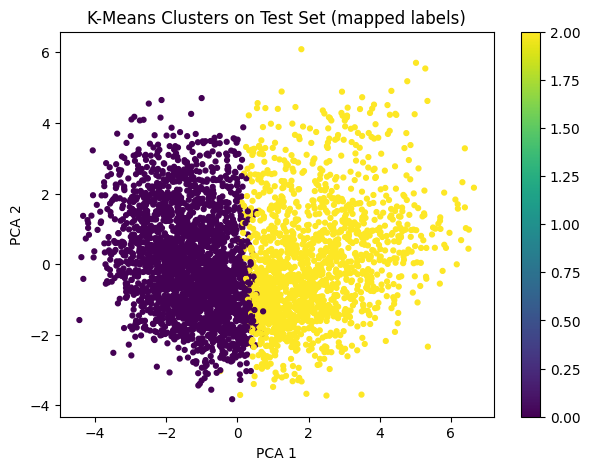

In [11]:

test_pred_kmeans = kmeans.predict(Xte_s)
res_kmeans_test = evaluate_predictions('K-Means', Xte_s, yte_s, test_pred_kmeans)

print(f"K-Means Test Accuracy : {res_kmeans_test['accuracy']:.4f}")
print(f"K-Means Test Coverage : {res_kmeans_test['coverage']:.4f}")
print(f"K-Means Silhouette    : {res_kmeans_test['silhouette']:.4f}")

plot_clusters_2d(Xte_s, res_kmeans_test['mapped_pred'], 'K-Means Clusters on Test Set (mapped labels)')


# **5. Hierarchical Clustering**

This group uses **Agglomerative Clustering**. Because hierarchical clustering has high computational costs, notebooks use a smaller sample for training, testing, and evaluation.

## ***5.1. Agglomerative Training and Validation***

In [12]:

agg = AgglomerativeClustering(n_clusters=3, linkage='ward')
train_pred_agg = agg.fit_predict(Xtr_h)

# AgglomerativeClustering không có predict(), nên fit riêng trên validation để kiểm định cấu trúc cụm
val_pred_agg = AgglomerativeClustering(n_clusters=3, linkage='ward').fit_predict(Xva_h)
res_agg_val = evaluate_predictions('Agglomerative (Validation)', Xva_h, yva_h, val_pred_agg)

pd.DataFrame([{
    'Accuracy': res_agg_val['accuracy'],
    'Coverage': res_agg_val['coverage'],
    'Silhouette': res_agg_val['silhouette'],
    'Mapping': str(res_agg_val['mapping'])
}])


,Accuracy,Coverage,Silhouette,Mapping
0,0.509167,1.0,0.060952,"{np.int64(0): np.int64(0), np.int64(1): np.int..."


## ***5.2. Agglomerative Test Accuracy and Visualization***

Agglomerative Test Accuracy : 0.4467
Agglomerative Test Coverage : 1.0000
Agglomerative Silhouette    : 0.1245


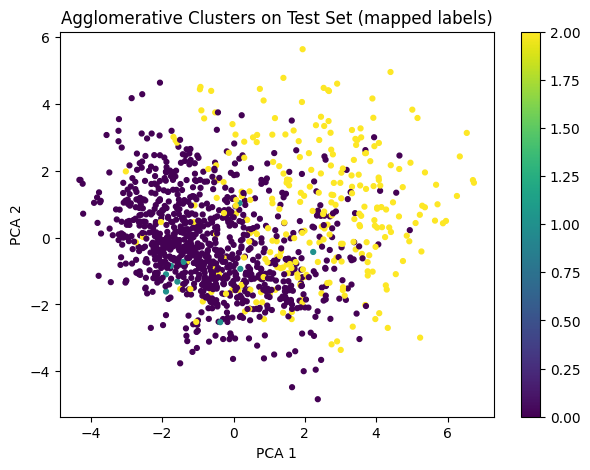

In [13]:

test_pred_agg = AgglomerativeClustering(n_clusters=3, linkage='ward').fit_predict(Xte_h)
res_agg_test = evaluate_predictions('Agglomerative', Xte_h, yte_h, test_pred_agg)

print(f"Agglomerative Test Accuracy : {res_agg_test['accuracy']:.4f}")
print(f"Agglomerative Test Coverage : {res_agg_test['coverage']:.4f}")
print(f"Agglomerative Silhouette    : {res_agg_test['silhouette']:.4f}")

plot_clusters_2d(Xte_h, res_agg_test['mapped_pred'], 'Agglomerative Clusters on Test Set (mapped labels)')


# **6. Density-based Clustering**

This group uses **DBSCAN**. The validation set is used to select the best pair of parameters `eps` and `min_samples` based on accuracy.

## ***6.1. Hyperparameter Search on Validation***

In [14]:

dbscan_candidates = []
for eps in [1.2, 1.4, 1.6, 1.8, 2.0]:
    for min_samples in [5, 10, 15, 20]:
        db = DBSCAN(eps=eps, min_samples=min_samples)
        val_pred = db.fit_predict(Xva_s)
        res = evaluate_predictions(f'DBSCAN eps={eps}, min_samples={min_samples}', Xva_s, yva_s, val_pred)
        dbscan_candidates.append({
            'eps': eps,
            'min_samples': min_samples,
            'accuracy': res['accuracy'],
            'coverage': res['coverage'],
            'silhouette': res['silhouette']
        })

val_dbscan_df = pd.DataFrame(dbscan_candidates).sort_values(by=['accuracy', 'coverage'], ascending=False).reset_index(drop=True)
val_dbscan_df.head(10)


,eps,min_samples,accuracy,coverage,silhouette
0,1.2,5,0.600000,0.00125,NaN
1,2.0,15,0.578947,0.00475,NaN
2,1.4,5,0.550000,0.00500,0.516337
3,1.8,10,0.550000,0.00500,NaN
4,2.0,10,0.461538,0.00650,NaN
5,1.6,5,0.400000,0.01125,0.378176
6,1.8,5,0.287671,0.01825,0.419985
7,2.0,5,0.200000,0.02875,0.409698
8,1.2,10,0.000000,0.00000,NaN
9,1.2,15,0.000000,0.00000,NaN


## ***6.2. DBSCAN Test Accuracy and Visualization***

Best params from validation -> eps=1.2, min_samples=5
DBSCAN Test Accuracy  : 0.6667
DBSCAN Test Coverage  : 0.0022
DBSCAN Silhouette     : nan
Coverage < 1 nghĩa là DBSCAN đã gán một số điểm là noise (-1).


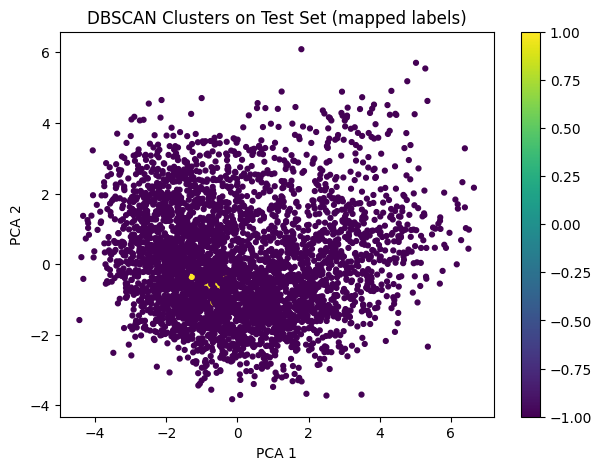

In [15]:

best_eps = float(val_dbscan_df.loc[0, 'eps'])
best_min_samples = int(val_dbscan_df.loc[0, 'min_samples'])

# DBSCAN không có predict(), nên fit riêng trên test với tham số đã chọn từ validation
best_dbscan = DBSCAN(eps=best_eps, min_samples=best_min_samples)
test_pred_dbscan = best_dbscan.fit_predict(Xte_s)
res_dbscan_test = evaluate_predictions('DBSCAN', Xte_s, yte_s, test_pred_dbscan)

print(f"Best params from validation -> eps={best_eps}, min_samples={best_min_samples}")
print(f"DBSCAN Test Accuracy  : {res_dbscan_test['accuracy']:.4f}")
print(f"DBSCAN Test Coverage  : {res_dbscan_test['coverage']:.4f}")
print(f"DBSCAN Silhouette     : {res_dbscan_test['silhouette']:.4f}")
print("Coverage < 1 nghĩa là DBSCAN đã gán một số điểm là noise (-1).")

plot_clusters_2d(Xte_s, res_dbscan_test['mapped_pred'], 'DBSCAN Clusters on Test Set (mapped labels)')


# **7. Model-based Clustering**

This group uses the **Gaussian Mixture Model (GMM)**, which corresponds to the model-based clustering concept, and optimizes using the **EM algorithm**.

## ***7.1. Gaussian Mixture Training and Validation***

In [16]:

gmm = GaussianMixture(n_components=3, covariance_type='full', random_state=RANDOM_STATE)
gmm.fit(Xtr_s)

val_pred_gmm = gmm.predict(Xva_s)
res_gmm_val = evaluate_predictions('Gaussian Mixture (Validation)', Xva_s, yva_s, val_pred_gmm)

pd.DataFrame([{
    'Accuracy': res_gmm_val['accuracy'],
    'Coverage': res_gmm_val['coverage'],
    'Silhouette': res_gmm_val['silhouette'],
    'Mapping': str(res_gmm_val['mapping'])
}])


,Accuracy,Coverage,Silhouette,Mapping
0,0.4445,1.0,0.012187,"{np.int64(0): np.int64(0), np.int64(1): np.int..."


## ***7.2. Gaussian Mixture Test Accuracy and Visualization***

Gaussian Mixture Test Accuracy : 0.4392
Gaussian Mixture Test Coverage : 1.0000
Gaussian Mixture Silhouette    : 0.0102


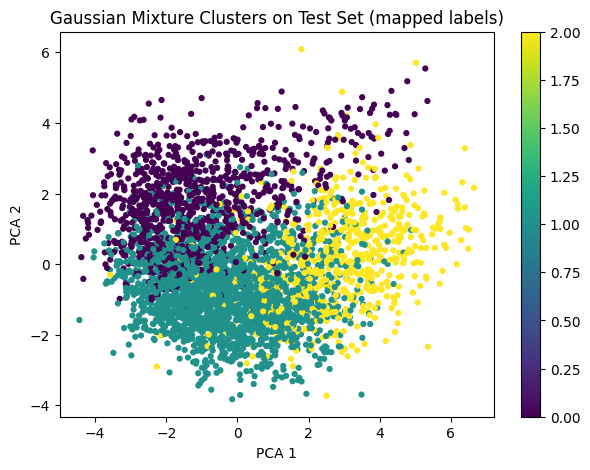

In [17]:

test_pred_gmm = gmm.predict(Xte_s)
res_gmm_test = evaluate_predictions('Gaussian Mixture', Xte_s, yte_s, test_pred_gmm)

print(f"Gaussian Mixture Test Accuracy : {res_gmm_test['accuracy']:.4f}")
print(f"Gaussian Mixture Test Coverage : {res_gmm_test['coverage']:.4f}")
print(f"Gaussian Mixture Silhouette    : {res_gmm_test['silhouette']:.4f}")

plot_clusters_2d(Xte_s, res_gmm_test['mapped_pred'], 'Gaussian Mixture Clusters on Test Set (mapped labels)')


# **8. Final Comparison on Test Set**


In [18]:

all_test_results = [
    res_kmeans_test,
    res_agg_test,
    res_dbscan_test,
    res_gmm_test,
]

comparison_df = results_table(all_test_results)
comparison_df


,Model,Accuracy,Coverage,Silhouette
0,DBSCAN,0.6667,0.0022,NaN
1,K-Means,0.5930,1.0000,0.0753
2,Agglomerative,0.4467,1.0000,0.1245
3,Gaussian Mixture,0.4392,1.0000,0.0102
